# DSC 288 Capstone — Google Analytics Revenue Prediction (EDA Notebook)

In this notebook, we focus on exploring the Google Analytics Customer Revenue Prediction dataset from Kaggle. The main goal here is to understand the structure of the data, identify the biggest challenges, and figure out what kind of modeling approach makes the most sense later on.

This notebook mainly covers the **EDA** side of the project. Since the dataset is large and includes nested fields, a big part of this work is just making the data easier to inspect and reason about.

This EDA is connected to the overall project goal:
- predict customer revenue
- use **transaction revenue** as the target
- compare a **single regression model** with a **two-step approach**
- evaluate performance using **RMSE on log-transformed revenue**


## 0. One-time install

If this is a fresh DataHub session, run the next cell once to install the required package.

If Kaggle was just installed in the current session, it is usually a good idea to **restart the kernel** before moving on. That helps avoid weird import issues later.


In [1]:

%pip install -q "kaggle>=1.8.0" pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Kaggle authentication for the new token system

Kaggle uses a newer token setup now, so this notebook uses:
- the `KAGGLE_API_TOKEN` environment variable
- a local `.kaggle/access_token` file



In [2]:

import os
from pathlib import Path
from getpass import getpass

token = "KGAT_1b9be33806319e3512562491581b274d"

if not token:
    raise ValueError("No token was provided.")

os.environ["KAGGLE_API_TOKEN"] = token

os.makedirs(".kaggle", exist_ok=True)
with open(".kaggle/access_token", "w") as f:
    f.write(token)

os.chmod(".kaggle/access_token", 0o600)
os.environ["KAGGLE_CONFIG_DIR"] = os.path.abspath(".kaggle")

print("Kaggle token configured.")
print("KAGGLE_CONFIG_DIR =", os.environ["KAGGLE_CONFIG_DIR"])

Kaggle token configured.
KAGGLE_CONFIG_DIR = /home/j1chanthabandith/private/DSC_288R/.kaggle


## 2. Download competition files

This section downloads the competition files directly into the DataHub environment.

If the download fails, the usual reasons are:
- the competition rules have not been accepted yet on Kaggle
- the API token is invalid or expired
- the kernel needs to be restarted after installation

Once that is set up correctly, the file download should work normally.


In [3]:

import os
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

zip_path = Path("ga-customer-revenue-prediction.zip")

if not zip_path.exists():
    api.competition_download_files(
        "ga-customer-revenue-prediction",
        path="."
    )
    print("Download finished.")
else:
    print("Zip already exists, skipping download.")

print("Current files:")
print(sorted(os.listdir("."))[:25])

Zip already exists, skipping download.
Current files:
['.ipynb_checkpoints', '.kaggle', 'dsc288_ga_revenue_eda_datahub_rewritten_with_missing_sections.ipynb', 'ga-customer-revenue-prediction.zip', 'test', 'train_v2.csv']


In [4]:

import zipfile
from pathlib import Path

zip_path = Path("ga-customer-revenue-prediction.zip")

if not zip_path.exists():
    raise FileNotFoundError("ga-customer-revenue-prediction.zip was not created.")

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    print("Files inside zip:", names)
    if "train_v2.csv" in names:
        z.extract("train_v2.csv", ".")
    else:
        z.extractall(".")

print("Extraction complete.")
print("train_v2.csv exists:", Path("train_v2.csv").exists())

Files inside zip: ['sample_submission.csv', 'sample_submission_v2.csv', 'test.csv', 'test_v2.csv', 'train.csv', 'train_v2.csv']
Extraction complete.
train_v2.csv exists: True


## 3. Imports and helper functions

This section loads the libraries I need for the EDA along with a few small helper functions.

The helper functions mostly make the notebook cleaner and save time when checking missing values, distributions, and grouped summaries.


In [5]:

import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas import json_normalize

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 4. Data loading strategy

The `train_v2.csv` file is large, so for EDA we are not loading the full dataset by default.

Instead, we use a sample size that is safer for DataHub:
- `nrows=50_000` for a lighter run
- `nrows=100_000` if the session can handle more

This is enough to get a strong first look at the data without running into memory problems too early.


In [6]:

DATA_PATH = "train_v2.csv"
JSON_COLUMNS = ["device", "geoNetwork", "totals", "trafficSource"]

if not Path(DATA_PATH).exists():
    raise FileNotFoundError("train_v2.csv not found. Run the download/extract cells first.")

def load_ga_data(path, json_columns=JSON_COLUMNS, nrows=50_000):
    df = pd.read_csv(
        path,
        converters={col: json.loads for col in json_columns},
        dtype={"fullVisitorId": "str"},
        nrows=nrows
    )

    for col in json_columns:
        col_df = json_normalize(df[col])
        col_df.columns = [f"{col}.{subcol}" for subcol in col_df.columns]
        df = df.drop(columns=[col]).merge(col_df, left_index=True, right_index=True)

    return df

df = load_ga_data(DATA_PATH, nrows=50_000)
print("Shape:", df.shape)
df.head()

Shape: (50000, 59)


,channelGrouping,customDimensions,date,fullVisitorId,hits,socialEngagementType,visitId,visitNumber,visitStartTime,device.browser,device.browserVersion,device.browserSize,device.operatingSystem,device.operatingSystemVersion,device.isMobile,device.mobileDeviceBranding,device.mobileDeviceModel,device.mobileInputSelector,device.mobileDeviceInfo,device.mobileDeviceMarketingName,device.flashVersion,device.language,device.screenColors,device.screenResolution,device.deviceCategory,geoNetwork.continent,geoNetwork.subContinent,geoNetwork.country,geoNetwork.region,geoNetwork.metro,geoNetwork.city,geoNetwork.cityId,geoNetwork.networkDomain,geoNetwork.latitude,geoNetwork.longitude,geoNetwork.networkLocation,totals.visits,totals.hits,totals.pageviews,totals.bounces,totals.newVisits,totals.sessionQualityDim,totals.timeOnSite,totals.transactions,totals.transactionRevenue,totals.totalTransactionRevenue,trafficSource.campaign,trafficSource.source,trafficSource.medium,trafficSource.keyword,trafficSource.adwordsClickInfo.criteriaParameters,trafficSource.referralPath,trafficSource.isTrueDirect,trafficSource.adContent,trafficSource.adwordsClickInfo.page,trafficSource.adwordsClickInfo.slot,trafficSource.adwordsClickInfo.gclId,trafficSource.adwordsClickInfo.adNetworkType,trafficSource.adwordsClickInfo.isVideoAd
0,Organic Search,"[{'index': '4', 'value': 'EMEA'}]",20171016,3162355547410993243,"[{'hitNumber': '1', 'time': '0', 'hour': '17',...",Not Socially Engaged,1508198450,1,1508198450,Firefox,not available in demo dataset,not available in demo dataset,Windows,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,desktop,Europe,Western Europe,Germany,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,(not set),not available in demo dataset,not available in demo dataset,not available in demo dataset,1,1,1,1,1,1,NaN,NaN,NaN,NaN,(not set),google,organic,water bottle,not available in demo dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Referral,"[{'index': '4', 'value': 'North America'}]",20171016,8934116514970143966,"[{'hitNumber': '1', 'time': '0', 'hour': '10',...",Not Socially Engaged,1508176307,6,1508176307,Chrome,not available in demo dataset,not available in demo dataset,Chrome OS,not available in demo dataset,False,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,desktop,Americas,Northern America,United States,California,San Francisco-Oakland-San Jose CA,Cupertino,not available in demo dataset,(not set),not available in demo dataset,not available in demo dataset,not available in demo dataset,1,2,2,NaN,NaN,2,28,NaN,NaN,NaN,(not set),sites.google.com,referral,NaN,not available in demo dataset,/a/google.com/transportation/mtv-services/bike...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Direct,"[{'index': '4', 'value': 'North America'}]",20171016,7992466427990357681,"[{'hitNumber': '1', 'time': '0', 'hour': '17',...",Not Socially Engaged,1508201613,1,1508201613,Chrome,not available in demo dataset,not available in demo dataset,Android,not available in demo dataset,True,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,mobile,Americas,Northern America,United States,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,windjammercable.net,not available in dem

## 5. Basic structure overview

Before getting into specific features, we first check the overall structure of the dataset.

That includes things like:
- shape of the data
- column names
- basic data types
- whether the nested fields were flattened correctly

This step is mainly to make sure the data loaded the way we expected before doing deeper analysis.


In [7]:

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

overview.head(30)

,dtype,missing_count,missing_pct,n_unique
totals.transactionRevenue,object,49532,99.0600,379
totals.totalTransactionRevenue,object,49532,99.0600,425
totals.transactions,object,49527,99.0500,4
trafficSource.adContent,object,48802,97.6000,47
trafficSource.adwordsClickInfo.isVideoAd,object,48422,96.8400,2
trafficSource.adwordsClickInfo.slot,object,48422,96.8400,3
trafficSource.adwordsClickInfo.adNetworkType,object,48422,96.8400,3
trafficSource.adwordsClickInfo.page,object,48422,96.8400,5
trafficSource.adwordsClickInfo.gclId,object,48387,96.7700,1484
trafficSource.keyword,object,37218,74.4400,179


## 6. Target engineering

The main target for this project is transaction revenue.

To make the later analysis easier, we create a few additional fields:
- `revenue`
- `has_revenue`
- `log_revenue`
- parsed date and visit-time features

These columns help separate the problem into two parts: whether revenue happens at all, and how large it is when it does happen.


In [8]:

df["revenue"] = pd.to_numeric(df.get("totals.transactionRevenue"), errors="coerce").fillna(0)
df["has_revenue"] = (df["revenue"] > 0).astype(int)
df["log_revenue"] = np.log1p(df["revenue"])

df["date"] = df["date"].astype(str)
df["date_parsed"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["visit_start_dt"] = pd.to_datetime(df["visitStartTime"], unit="s", errors="coerce")

df["year"] = df["date_parsed"].dt.year
df["month"] = df["date_parsed"].dt.to_period("M").astype(str)
df["day_of_week"] = df["date_parsed"].dt.day_name()
df["hour"] = df["visit_start_dt"].dt.hour

for col in ["totals.hits", "totals.pageviews", "totals.bounces", "totals.newVisits", "visitNumber"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df[["fullVisitorId", "revenue", "has_revenue", "log_revenue", "date_parsed"]].head()

,fullVisitorId,revenue,has_revenue,log_revenue,date_parsed
0,3162355547410993243,0.0000,0,0.0000,2017-10-16
1,8934116514970143966,0.0000,0,0.0000,2017-10-16
2,7992466427990357681,0.0000,0,0.0000,2017-10-16
3,9075655783635761930,0.0000,0,0.0000,2017-10-16
4,6960673291025684308,0.0000,0,0.0000,2017-10-16


## 7. Target EDA: zero inflation and skew

This is one of the most important parts of the notebook.

Here we look at the target distribution to answer a few key questions:
- Is most of the revenue actually zero?
- How skewed is the positive revenue?
- Does it make sense to model this as a two-step problem?

From a modeling perspective, this section matters a lot because extremely zero-heavy and skewed targets are usually hard for standard regression models to handle well.


In [9]:

target_summary = pd.Series({
    "total_sessions": len(df),
    "positive_revenue_sessions": int(df["has_revenue"].sum()),
    "zero_revenue_sessions": int((df["has_revenue"] == 0).sum()),
    "positive_rate_pct": round(df["has_revenue"].mean() * 100, 4),
    "mean_revenue": df["revenue"].mean(),
    "median_revenue": df["revenue"].median(),
    "max_revenue": df["revenue"].max()
})
target_summary.to_frame("value")

,value
total_sessions,"50,000.0000"
positive_revenue_sessions,468.0000
zero_revenue_sessions,"49,532.0000"
positive_rate_pct,0.9360
mean_revenue,"1,203,764.4000"
median_revenue,0.0000
max_revenue,"5,498,000,000.0000"


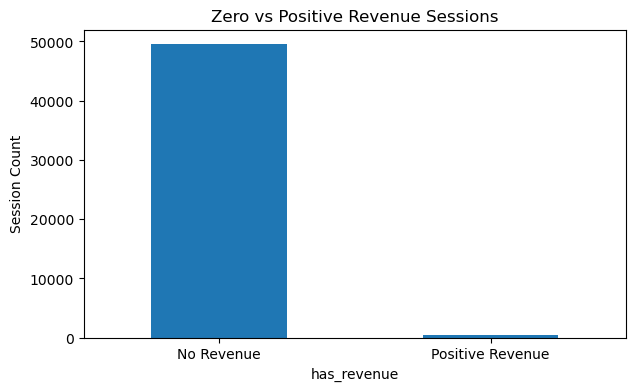

In [10]:

plt.figure(figsize=(7, 4))
df["has_revenue"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Revenue", "Positive Revenue"], rotation=0)
plt.ylabel("Session Count")
plt.title("Zero vs Positive Revenue Sessions")
plt.show()

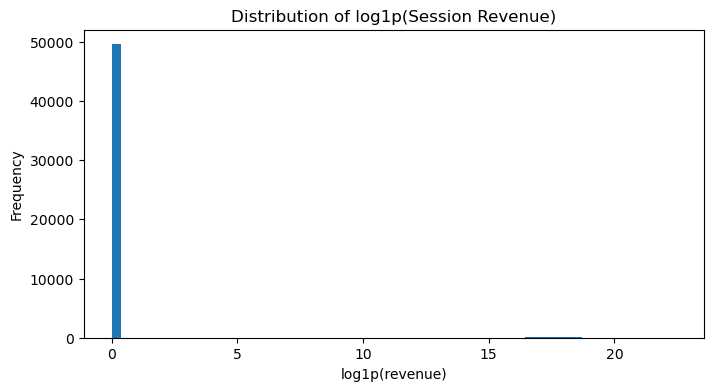

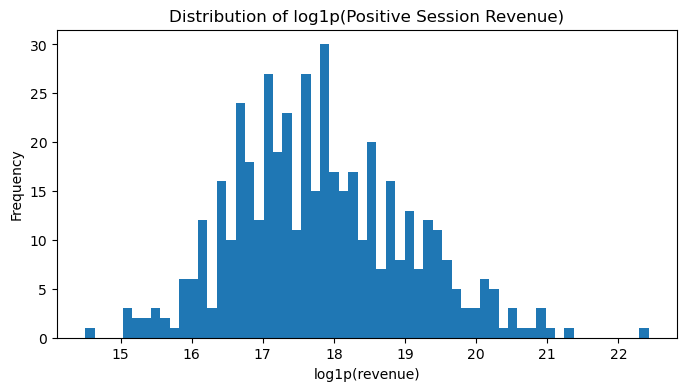

In [11]:

plt.figure(figsize=(8, 4))
df["log_revenue"].plot(kind="hist", bins=60)
plt.title("Distribution of log1p(Session Revenue)")
plt.xlabel("log1p(revenue)")
plt.ylabel("Frequency")
plt.show()

positive_rev = df.loc[df["revenue"] > 0, "revenue"]
if len(positive_rev) > 0:
    plt.figure(figsize=(8, 4))
    np.log1p(positive_rev).plot(kind="hist", bins=60)
    plt.title("Distribution of log1p(Positive Session Revenue)")
    plt.xlabel("log1p(revenue)")
    plt.ylabel("Frequency")
    plt.show()

## 8. Missing-value analysis

Next, we check how much missing data shows up across the columns.

This helps answer a few practical questions:
- which columns are mostly empty
- which missing values might still be informative
- which features may need to be dropped, imputed, or simplified later

Since this dataset comes from web analytics logs, missingness is not always random, so it is worth examining carefully.


In [12]:

missing_df = (
    df.isna().mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
)
missing_df.columns = ["column", "missing_pct"]
missing_df.head(25)

,column,missing_pct
0,totals.transactionRevenue,99.0600
1,totals.totalTransactionRevenue,99.0600
2,totals.transactions,99.0500
3,trafficSource.adContent,97.6000
4,trafficSource.adwordsClickInfo.page,96.8400
5,trafficSource.adwordsClickInfo.slot,96.8400
6,trafficSource.adwordsClickInfo.adNetworkType,96.8400
7,trafficSource.adwordsClickInfo.isVideoAd,96.8400
8,trafficSource.adwordsClickInfo.gclId,96.7700
9,trafficSource.keyword,74.4400


## 9. Low-variance / near-constant columns

After checking missing values, we also look for columns that barely change.

These kinds of columns usually do not add much information and can sometimes just create unnecessary noise. Identifying them early helps clean up the feature space before modeling.


In [13]:

nunique_df = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[col].nunique(dropna=False) for col in df.columns]
}).sort_values("n_unique")

nunique_df.head(30)

,column,n_unique
10,device.browserVersion,1
11,device.browserSize,1
13,device.operatingSystemVersion,1
15,device.mobileDeviceBranding,1
50,trafficSource.adwordsClickInfo.criteriaParameters,1
18,device.mobileDeviceInfo,1
17,device.mobileInputSelector,1
16,device.mobileDeviceModel,1
21,device.language,1
20,device.flashVersion,1


## 10. Numeric behavior features

This section focuses on a few numeric behavior variables that are likely to matter later:
- hits
- pageviews
- visit number
- bounces
- new visits

These are useful because they give a quick sense of how engaged a session was. we want to see whether stronger engagement patterns line up with higher conversion or higher revenue.


In [14]:

numeric_cols = [col for col in [
    "totals.hits", "totals.pageviews", "visitNumber",
    "totals.bounces", "totals.newVisits",
    "revenue", "log_revenue"
] if col in df.columns]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
totals.hits,"50,000.0000",4.3505,8.8381,1.0000,1.0000,1.0000,4.0000,331.0000
totals.pageviews,"49,994.0000",3.6315,6.3103,1.0000,1.0000,1.0000,3.0000,197.0000
visitNumber,"50,000.0000",2.2737,8.3531,1.0000,1.0000,1.0000,1.0000,401.0000
totals.bounces,"25,398.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
totals.newVisits,"38,473.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
revenue,"50,000.0000","1,203,764.4000","32,930,678.6987",0.0000,0.0000,0.0000,0.0000,"5,498,000,000.0000"
log_revenue,"50,000.0000",0.1668,1.7202,0.0000,0.0000,0.0000,0.0000,22.4277


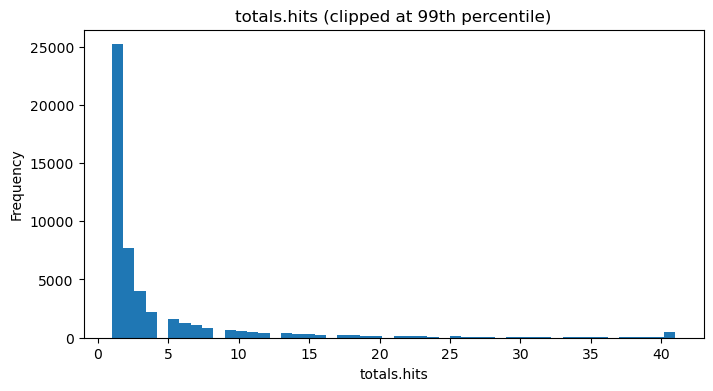

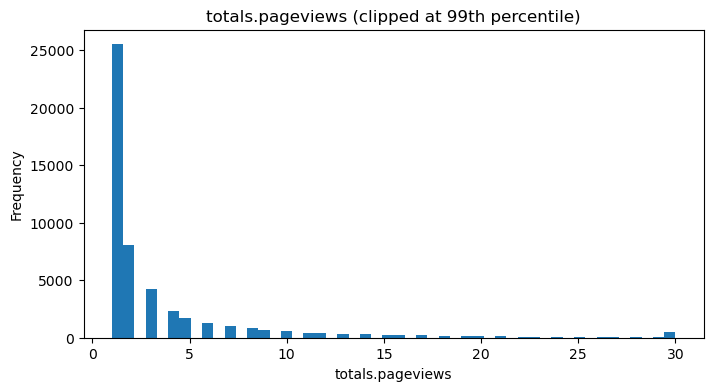

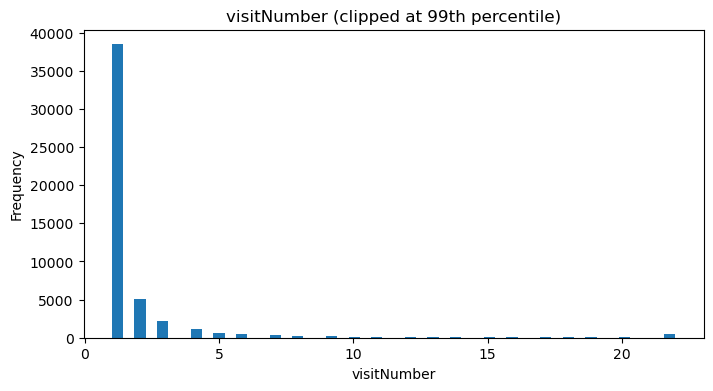

In [15]:

plot_cols = [col for col in ["totals.hits", "totals.pageviews", "visitNumber"] if col in df.columns]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    df[col].dropna().clip(upper=df[col].quantile(0.99)).plot(kind="hist", bins=50)
    plt.title(f"{col} (clipped at 99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [16]:

behavior_cols = [col for col in ["totals.hits", "totals.pageviews", "visitNumber", "totals.bounces", "totals.newVisits"] if col in df.columns]

grouped_stats = {}
for col in behavior_cols:
    grouped_stats[col] = df.groupby("has_revenue")[col].mean()

behavior_compare = pd.DataFrame(grouped_stats).T
behavior_compare.columns = ["mean_if_no_revenue", "mean_if_positive_revenue"]
behavior_compare

,mean_if_no_revenue,mean_if_positive_revenue
totals.hits,4.0474,36.4209
totals.pageviews,3.4055,27.5534
visitNumber,2.2603,3.6838
totals.bounces,1.0000,NaN
totals.newVisits,1.0000,1.0000


## 11. Categorical EDA for major project feature groups

Here we explore the main categorical feature groups used throughout the project:
- traffic source
- device information
- geography
- channel grouping

The goal is not to fully engineer every categorical variable yet, but to get a sense of which categories appear most often and whether some groups seem more connected to purchases than others.


In [17]:

cat_cols = [
    "channelGrouping",
    "device.deviceCategory",
    "device.browser",
    "device.operatingSystem",
    "geoNetwork.country",
    "trafficSource.medium",
    "trafficSource.source"
]
cat_cols = [c for c in cat_cols if c in df.columns]

def top_category_summary(data, col, top_n=10):
    top_values = data[col].fillna("Missing").value_counts().head(top_n).index
    subset = data[data[col].fillna("Missing").isin(top_values)].copy()
    subset[col] = subset[col].fillna("Missing")

    summary = subset.groupby(col).agg(
        sessions=("fullVisitorId", "count"),
        positive_rate=("has_revenue", "mean"),
        mean_log_revenue=("log_revenue", "mean"),
        mean_revenue=("revenue", "mean")
    ).sort_values("sessions", ascending=False)

    summary["positive_rate"] = (summary["positive_rate"] * 100).round(3)
    return summary

for col in cat_cols:
    print(f"\n===== {col} =====")
    display(top_category_summary(df, col, top_n=10))


===== channelGrouping =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
channelGrouping,,,,
Organic Search,21270,0.6350,0.1123,"608,396.3329"
Social,12083,0.0250,0.0041,"6,493.4205"
Direct,7305,0.9580,0.1711,"2,148,602.3272"
Referral,6179,3.8190,0.6844,"4,698,525.6514"
Paid Search,1279,1.4860,0.2609,"1,275,089.9140"
Affiliates,943,0.0000,0.0000,0.0000
Display,940,0.5320,0.0963,"862,340.4255"
(Other),1,0.0000,0.0000,0.0000



===== device.deviceCategory =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
device.deviceCategory,,,,
desktop,36124,1.1710,0.2092,"1,581,502.3253"
mobile,12258,0.3260,0.0567,"230,937.3470"
tablet,1618,0.3090,0.0539,"140,420.2719"



===== device.browser =====


...

,sessions,positive_rate,mean_log_revenue,mean_revenue
geoNetwork.country,,,,
United States,19533,2.3090,0.4115,"2,973,614.9081"
India,3058,0.0000,0.0000,0.0000
United Kingdom,2071,0.0000,0.0000,0.0000
Vietnam,1695,0.0000,0.0000,0.0000
Canada,1419,0.4230,0.0776,"912,762.5088"
Brazil,1187,0.0000,0.0000,0.0000
Thailand,1151,0.0000,0.0000,0.0000
Germany,1111,0.0000,0.0000,0.0000
Turkey,1049,0.0000,0.0000,0.0000



===== trafficSource.medium =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
trafficSource.medium,,,,
(none),21399,1.7900,0.3194,"2,388,612.5520"
referral,14376,0.0830,0.0148,"98,865.4702"
organic,11778,0.5090,0.0899,"492,679.5721"
cpc,1225,0.7350,0.1315,"876,416.3265"
affiliate,943,0.0000,0.0000,0.0000
cpm,278,1.4390,0.2633,"2,793,597.1223"
(not set),1,0.0000,0.0000,0.0000



===== trafficSource.source =====


,sessions,positive_rate,mean_log_revenue,mean_revenue
trafficSource.source,,,,
(direct),21399,1.7900,0.3194,"2,388,612.5520"
google,12716,0.5350,0.0943,"426,626.2976"
youtube.com,11597,0.0090,0.0014,"1,465.0341"
analytics.google.com,1150,0.0000,0.0000,0.0000
Partners,944,0.0000,0.0000,0.0000
sites.google.com,267,1.1240,0.2033,"2,287,940.0749"
google.com,264,0.7580,0.1281,"166,590.9091"
dfa,240,1.6670,0.3050,"3,235,916.6667"
baidu,138,0.0000,0.0000,0.0000


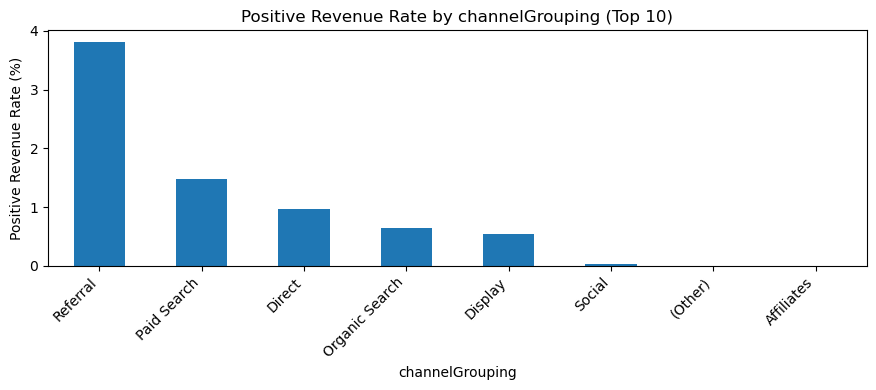

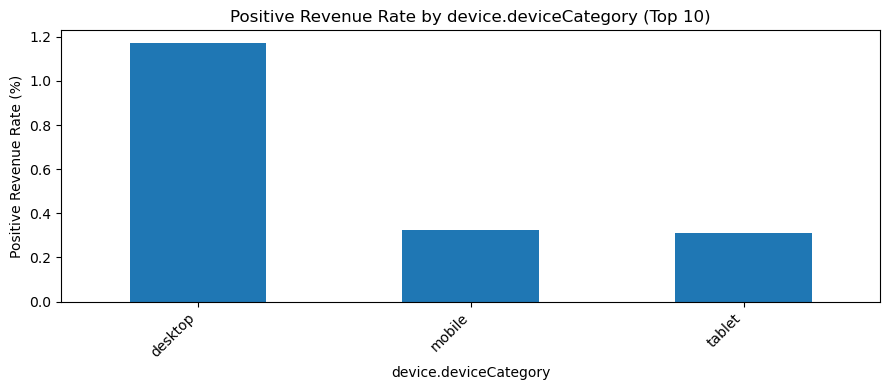

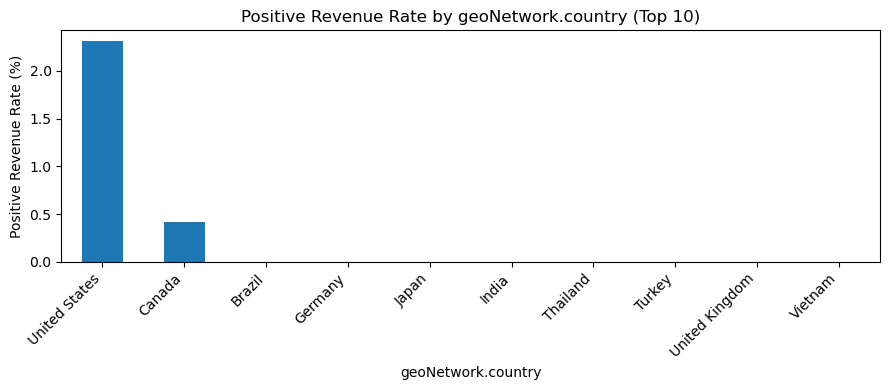

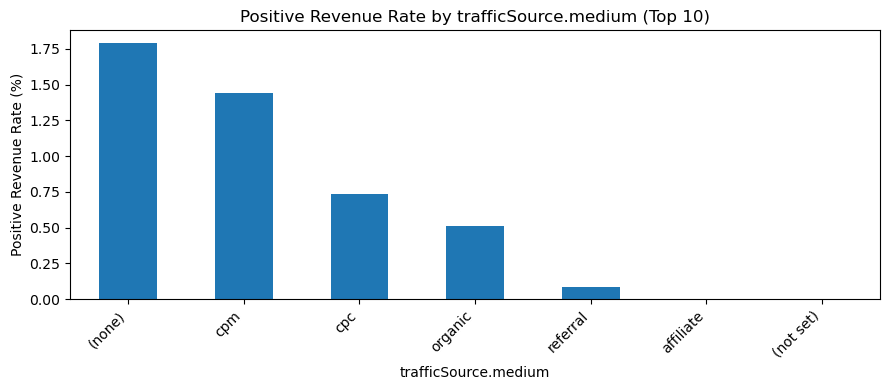

In [18]:

def plot_top_categories(data, col, top_n=10):
    top_values = data[col].fillna("Missing").value_counts().head(top_n).index
    subset = data[data[col].fillna("Missing").isin(top_values)].copy()
    subset[col] = subset[col].fillna("Missing")

    rates = subset.groupby(col)["has_revenue"].mean().sort_values(ascending=False).mul(100)

    plt.figure(figsize=(9, 4))
    rates.plot(kind="bar")
    plt.title(f"Positive Revenue Rate by {col} (Top {top_n})")
    plt.ylabel("Positive Revenue Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in [c for c in ["channelGrouping", "device.deviceCategory", "geoNetwork.country", "trafficSource.medium"] if c in df.columns]:
    plot_top_categories(df, col, top_n=10)

## 12. Time-based EDA

Because this is session and visit data, time features are also worth checking.

In this section, we look at patterns by:
- month
- day of week
- hour

Even if these features are not the strongest predictors by themselves, they can still add useful signal once they are combined with the rest of the behavior data.


In [19]:

monthly = df.groupby("month").agg(
    sessions=("fullVisitorId", "count"),
    positive_rate=("has_revenue", "mean"),
    total_revenue=("revenue", "sum"),
    avg_log_revenue=("log_revenue", "mean")
).reset_index()

monthly["positive_rate"] = monthly["positive_rate"] * 100
monthly

,month,sessions,positive_rate,total_revenue,avg_log_revenue
0,2016-08,2667,1.6873,"7,427,120,000.0000",0.3077
1,2016-09,2613,1.0333,"4,322,440,000.0000",0.1871
2,2016-11,10828,0.6926,"10,250,670,000.0000",0.1248
3,2017-01,4176,1.3170,"6,884,800,000.0000",0.2357
4,2017-02,2182,1.3291,"4,583,980,000.0000",0.2403
5,2017-03,1781,0.6176,"576,290,000.0000",0.1052
6,2017-06,6633,1.6282,"16,272,340,000.0000",0.2885
7,2017-10,2989,0.8029,"1,655,420,000.0000",0.1379
8,2017-11,8835,0.4754,"3,950,390,000.0000",0.0850
9,2018-01,5207,0.7298,"3,680,870,000.0000",0.1278


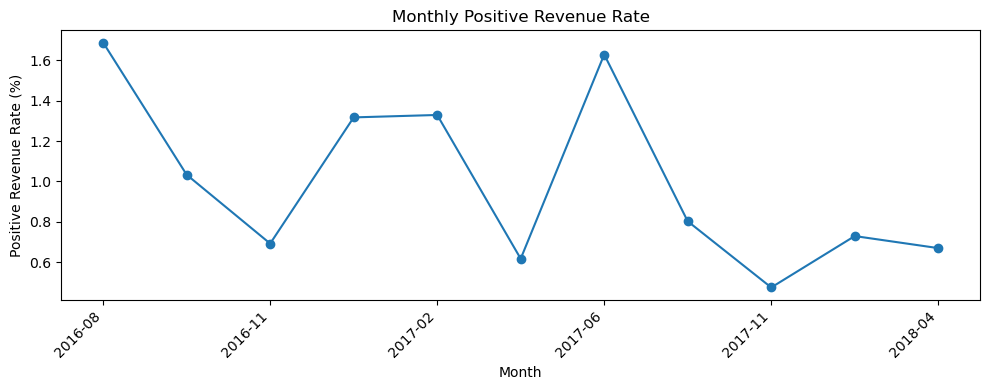

In [20]:

plt.figure(figsize=(10, 4))
df.groupby("month")["has_revenue"].mean().mul(100).plot(marker="o")
plt.title("Monthly Positive Revenue Rate")
plt.ylabel("Positive Revenue Rate (%)")
plt.xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

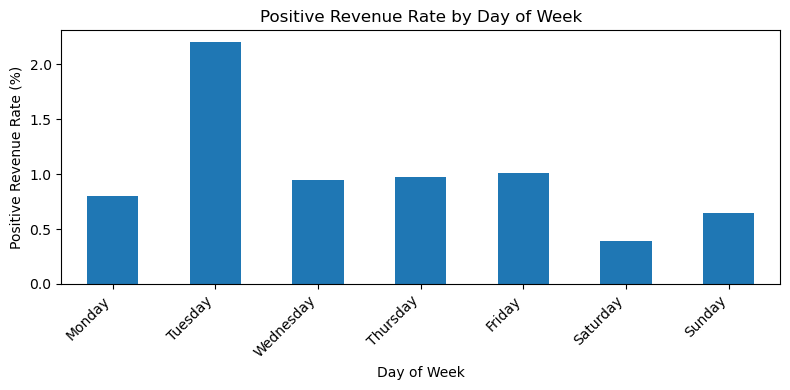

In [21]:

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df.groupby("day_of_week")["has_revenue"].mean().reindex(order).mul(100)

plt.figure(figsize=(8, 4))
dow.plot(kind="bar")
plt.title("Positive Revenue Rate by Day of Week")
plt.ylabel("Positive Revenue Rate (%)")
plt.xlabel("Day of Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

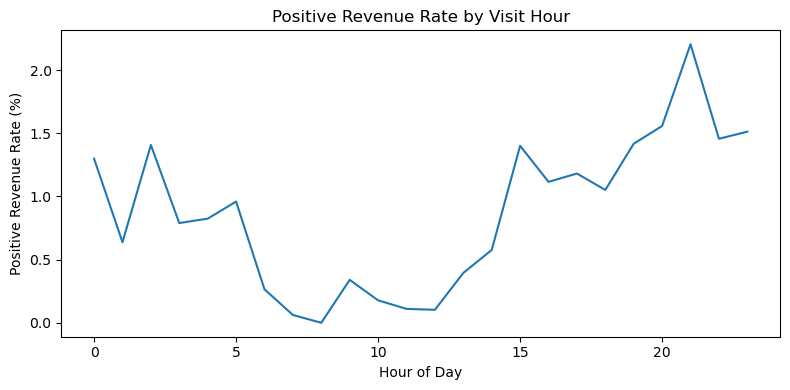

In [22]:

hour_rate = df.groupby("hour")["has_revenue"].mean().mul(100)

plt.figure(figsize=(8, 4))
hour_rate.plot()
plt.title("Positive Revenue Rate by Visit Hour")
plt.ylabel("Positive Revenue Rate (%)")
plt.xlabel("Hour of Day")
plt.tight_layout()
plt.show()

## 13. Visitor-level aggregation

Although the raw dataset is session-level, the bigger project question is really about customer revenue.

Because of that, it makes sense to aggregate sessions at the `fullVisitorId` level and build visitor-level summaries. This helps capture repeated behavior across multiple visits instead of treating every session like it belongs to a completely separate user.

That kind of aggregation will likely matter more once the project moves from EDA into modeling.


In [23]:

agg_dict = {
    "revenue": ["sum", "max", "mean"],
    "has_revenue": ["max", "mean"],
    "visitNumber": ["max"],
}

optional_numeric = ["totals.hits", "totals.pageviews", "totals.bounces", "totals.newVisits"]
for col in optional_numeric:
    if col in df.columns:
        agg_dict[col] = ["mean", "max"]

agg_dict["date_parsed"] = ["min", "max", "count"]

visitor_df = df.groupby("fullVisitorId").agg(agg_dict)
visitor_df.columns = ["_".join(col).strip() for col in visitor_df.columns]
visitor_df = visitor_df.reset_index()

visitor_df = visitor_df.rename(columns={
    "revenue_sum": "visitor_total_revenue",
    "revenue_max": "visitor_max_session_revenue",
    "revenue_mean": "visitor_avg_session_revenue",
    "has_revenue_max": "visitor_has_any_revenue",
    "has_revenue_mean": "visitor_purchase_session_rate",
    "visitNumber_max": "visitor_max_visit_number",
    "date_parsed_count": "visitor_session_count",
    "date_parsed_min": "first_seen_date",
    "date_parsed_max": "last_seen_date",
})

visitor_df["visitor_active_days"] = (
    visitor_df["last_seen_date"] - visitor_df["first_seen_date"]
).dt.days

visitor_df["visitor_log_total_revenue"] = np.log1p(visitor_df["visitor_total_revenue"])

print("Visitor-level shape:", visitor_df.shape)
visitor_df.head()

Visitor-level shape: (45639, 20)


,fullVisitorId,visitor_total_revenue,visitor_max_session_revenue,visitor_avg_session_revenue,visitor_has_any_revenue,visitor_purchase_session_rate,visitor_max_visit_number,totals.hits_mean,totals.hits_max,totals.pageviews_mean,totals.pageviews_max,totals.bounces_mean,totals.bounces_max,totals.newVisits_mean,totals.newVisits_max,first_seen_date,last_seen_date,visitor_session_count,visitor_active_days,visitor_log_total_revenue
0,0000174067426171406,0.0000,0.0000,0.0000,0,0.0000,1,28.0000,28,25.0000,25.0000,NaN,NaN,1.0000,1.0000,2016-11-10,2016-11-10,1,0,0.0000
1,0000245437374675368,0.0000,0.0000,0.0000,0,0.0000,1,2.0000,2,2.0000,2.0000,NaN,NaN,1.0000,1.0000,2016-09-02,2016-09-02,1,0,0.0000
2,0000593255797039768,0.0000,0.0000,0.0000,0,0.0000,2,5.5000,9,5.5000,9.0000,NaN,NaN,1.0000,1.0000,2018-04-15,2018-04-15,2,0,0.0000
3,0000750929315523353,0.0000,0.0000,0.0000,0,0.0000,1,1.0000,1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2017-02-03,2017-02-03,1,0,0.0000
4,0000955020478109523,0.0000,0.0000,0.0000,0,0.0000,1,1.0000,1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2018-01-03,2018-01-03,1,0,0.0000


In [24]:

visitor_summary = pd.Series({
    "unique_visitors": visitor_df["fullVisitorId"].nunique(),
    "visitors_with_any_revenue": int(visitor_df["visitor_has_any_revenue"].sum()),
    "visitor_positive_rate_pct": round(visitor_df["visitor_has_any_revenue"].mean() * 100, 4),
    "avg_sessions_per_visitor": round(visitor_df["visitor_session_count"].mean(), 4)
})
visitor_summary.to_frame("value")

,value
unique_visitors,"45,639.0000"
visitors_with_any_revenue,460.0000
visitor_positive_rate_pct,1.0079
avg_sessions_per_visitor,1.0956


## 14. Explicit data health check summary

Before wrapping up the EDA, we wanted to summarize the basic health of the dataset in one place. This makes the notebook line up better with a standard EDA workflow and helps confirm that the data is in a usable state before modeling.

In this section, I check:
- dataset shape
- data types
- missingness
- duplicate rows
- low-variance columns

This is useful because EDA is not just about plotting charts. It is also about making sure the dataset is clean, complete enough to use, and consistent with what we expect from the raw source.

In [25]:
duplicate_rows = int(df.duplicated().sum())

health_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "duplicate_row_count",
        "duplicate_row_pct",
        "numeric_column_count",
        "object_column_count",
        "datetime_column_count",
        "columns_with_missing_values",
        "columns_over_50pct_missing",
        "near_constant_columns"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        duplicate_rows,
        round((duplicate_rows / len(df)) * 100, 4) if len(df) else 0,
        int((df.dtypes != "object").sum()),
        int((df.dtypes == "object").sum()),
        int(sum("datetime64" in str(dtype) for dtype in df.dtypes)),
        int((df.isna().sum() > 0).sum()),
        int((df.isna().mean() > 0.50).sum()),
        int((nunique_df["n_unique"] <= 1).sum())
    ]
})

health_summary

,metric,value
0,row_count,"50,000.0000"
1,column_count,68.0000
2,duplicate_row_count,0.0000
3,duplicate_row_pct,0.0000
4,numeric_column_count,15.0000
5,object_column_count,53.0000
6,datetime_column_count,2.0000
7,columns_with_missing_values,17.0000
8,columns_over_50pct_missing,14.0000
9,near_constant_columns,19.0000


A few quick takeaways from the health check:

- The dataset is large enough that sampling makes sense for notebook-based EDA.
- Missing values are present in several columns, and some are substantial enough that they will matter during feature engineering.
- Duplicate rows and near-constant columns are worth checking early because they can add noise without adding much information.
- Data type validation matters here because this dataset mixes nested JSON-style fields, numeric behavior columns, and parsed date features.

Overall, the dataset looks usable, but it definitely needs thoughtful preprocessing rather than a straight jump into modeling.

## 15. Outlier analysis

Another thing I wanted to check more directly is whether extreme values are showing up in the main numeric features.

For this project, outliers are especially important because:
- revenue is heavily right-skewed
- behavior variables like hits and pageviews can also have very large values
- some extreme values may be real user behavior rather than data errors

So instead of removing them automatically, I want to see how serious they are first and decide whether transformation or clipping makes more sense.

In [26]:
outlier_cols = [col for col in ["revenue", "log_revenue", "totals.hits", "totals.pageviews", "visitNumber"] if col in df.columns]

outlier_summary = []
for col in outlier_cols:
    series = df[col].dropna()
    if len(series) == 0:
        continue
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    lower_fence = q1 - 1.5 * iqr
    outlier_count = int(((series < lower_fence) | (series > upper_fence)).sum())
    outlier_summary.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence,
        "outlier_count": outlier_count,
        "outlier_pct": round((outlier_count / len(series)) * 100, 4)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
0,revenue,0.0000,0.0000,0.0000,0.0000,0.0000,468,0.9360
1,log_revenue,0.0000,0.0000,0.0000,0.0000,0.0000,468,0.9360
2,totals.hits,1.0000,4.0000,3.0000,-3.5000,8.5000,6051,12.1020
3,totals.pageviews,1.0000,3.0000,2.0000,-2.0000,6.0000,6850,13.7016
4,visitNumber,1.0000,1.0000,0.0000,1.0000,1.0000,11527,23.0540


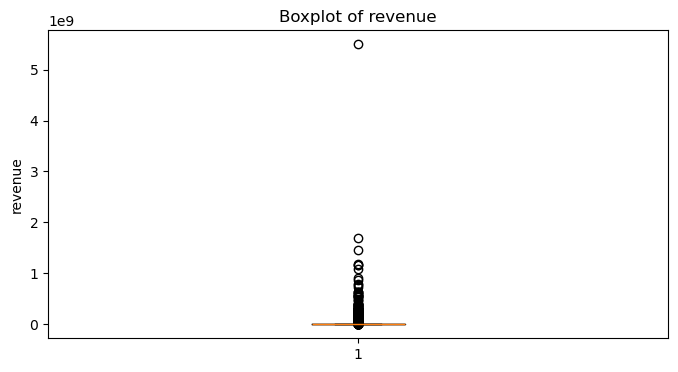

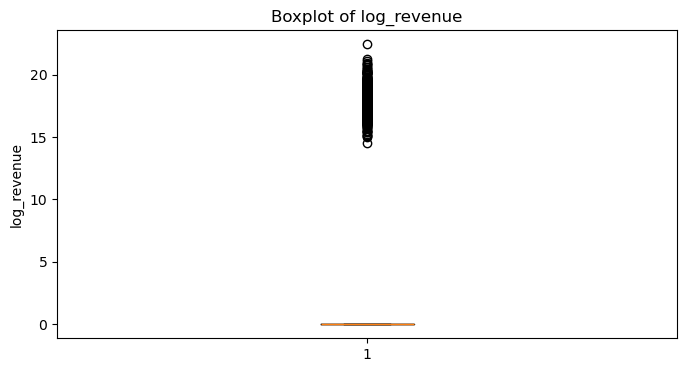

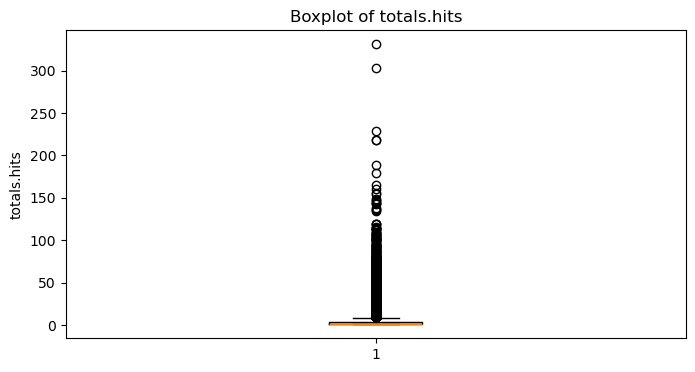

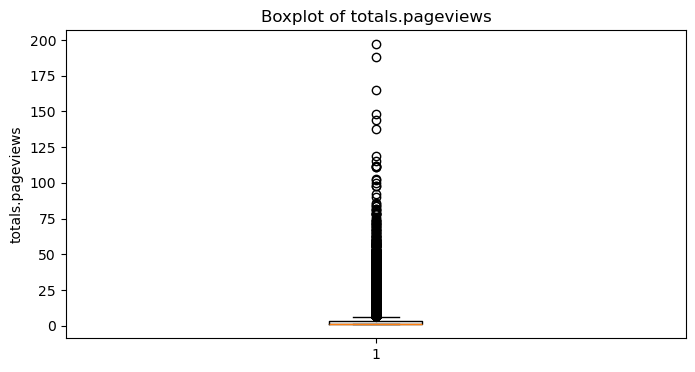

In [27]:
plot_cols = [col for col in ["revenue", "log_revenue", "totals.hits", "totals.pageviews"] if col in df.columns]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

From the outlier check, the main pattern is pretty clear: the extreme values are not just random noise. They are part of the structure of the dataset.

That matters because:
- high revenue values likely represent genuine high-value sessions
- high engagement values may capture unusually active browsing behavior
- removing all outliers would probably throw away useful signal

Because of that, the better choice here is usually to use transformations like `log1p`, percentile clipping for plots, or robust modeling choices later instead of blindly deleting extreme rows.

## 16. Multivariate analysis

Up to this point, most of the notebook has focused on one variable at a time or on grouped summaries. To make the EDA more complete, I also want to look at how multiple numeric features relate to each other and to the target.

This is useful because revenue usually does not depend on one feature alone. It is more realistic that several behavior variables interact together, even if each one only has a moderate relationship by itself.

In [28]:
corr_cols = [col for col in [
    "revenue",
    "log_revenue",
    "has_revenue",
    "totals.hits",
    "totals.pageviews",
    "visitNumber",
    "totals.bounces",
    "totals.newVisits",
    "hour"
] if col in df.columns]

corr_df = df[corr_cols].corr(numeric_only=True).round(3)
corr_df

,revenue,log_revenue,has_revenue,totals.hits,totals.pageviews,visitNumber,totals.bounces,totals.newVisits,hour
revenue,1.0000,0.4130,0.3760,0.1750,0.1790,0.0230,NaN,NaN,0.0150
log_revenue,0.4130,1.0000,0.9980,0.3570,0.3720,0.0170,NaN,NaN,0.0320
has_revenue,0.3760,0.9980,1.0000,0.3530,0.3690,0.0160,NaN,NaN,0.0310
totals.hits,0.1750,0.3570,0.3530,1.0000,0.9830,0.0220,NaN,NaN,0.0230
totals.pageviews,0.1790,0.3720,0.3690,0.9830,1.0000,0.0230,NaN,NaN,0.0260
visitNumber,0.0230,0.0170,0.0160,0.0220,0.0230,1.0000,NaN,NaN,0.0210
totals.bounces,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
totals.newVisits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,0.0150,0.0320,0.0310,0.0230,0.0260,0.0210,NaN,NaN,1.0000


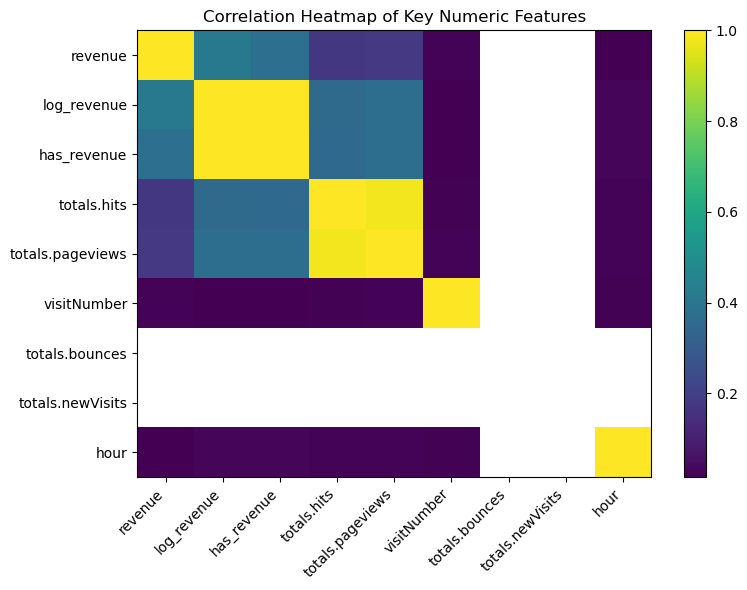

In [29]:
if len(corr_cols) >= 2:
    plt.figure(figsize=(8, 6))
    plt.imshow(corr_df, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_df.index)), corr_df.index)
    plt.title("Correlation Heatmap of Key Numeric Features")
    plt.tight_layout()
    plt.show()

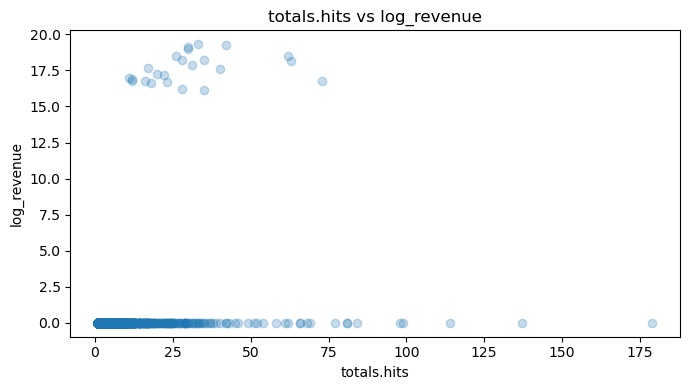

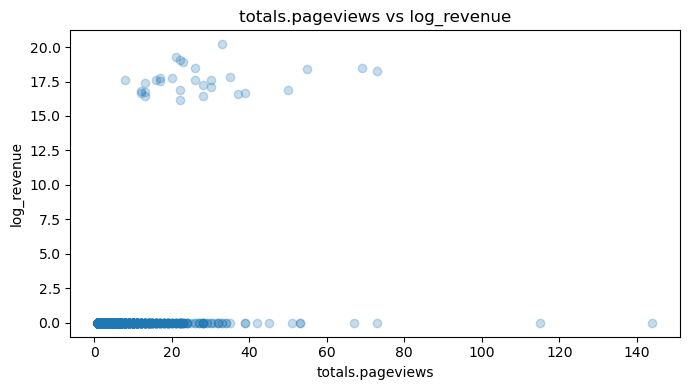

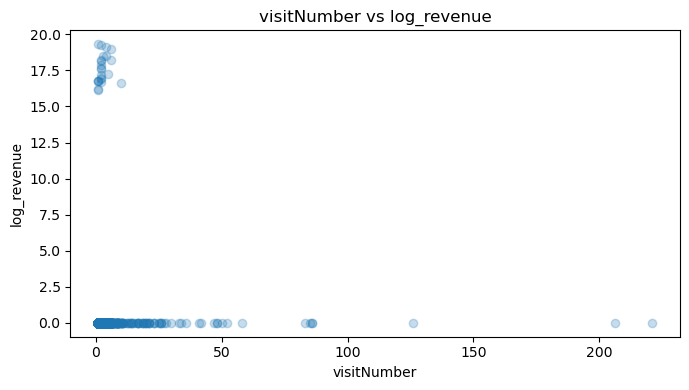

In [30]:
scatter_cols = [col for col in ["totals.hits", "totals.pageviews", "visitNumber"] if col in df.columns]

for col in scatter_cols:
    sample_df = df[[col, "log_revenue"]].dropna().sample(min(3000, len(df[[col, "log_revenue"]].dropna())), random_state=42)
    plt.figure(figsize=(7, 4))
    plt.scatter(sample_df[col], sample_df["log_revenue"], alpha=0.25)
    plt.title(f"{col} vs log_revenue")
    plt.xlabel(col)
    plt.ylabel("log_revenue")
    plt.tight_layout()
    plt.show()

The multivariate results suggest that no single variable completely explains revenue by itself, which is honestly what we expected for this kind of customer behavior data.

A few useful takeaways here are:
- engagement style variables like hits, pageviews, and visit number are still worth keeping
- some relationships appear weak on their own, but that does not mean they are useless in a model
- this supports using models that can combine multiple signals instead of relying on one simple rule

## 17. Hypotheses generated from EDA

After going through the main patterns in the dataset, we can now state a few hypotheses that the modeling stage should test more directly:

1. Visitors with stronger engagement behavior, such as more hits or pageviews, are more likely to generate revenue.
2. Some traffic acquisition channels bring in users who are more likely to convert than others.
3. Visitor level aggregation should perform better than session only modeling because repeated behavior across sessions carries useful information.
4. A single regression model may struggle because the target is zero inflated and strongly skewed.
5. A two-step setup, where conversion is predicted first and revenue amount is predicted second, is likely to work better.

These are not final conclusions yet. They are working hypotheses that came out of EDA and should be tested during the modeling stage.

## 18. Final EDA summary

At this point, the notebook covers the main pieces of an exploratory analysis:

- understanding the dataset structure
- checking types, missingness, and low-information columns
- looking at target imbalance and skew
- studying numeric behavior features
- comparing key categorical groups
- examining time-based patterns
- aggregating to the visitor level
- checking outliers and multivariate relationships

The biggest overall takeaway is that this dataset is informative, but it is also messy in a very realistic way. Most sessions have no revenue, positive revenue is highly skewed, and different feature groups seem to contribute small to moderate pieces of signal rather than one single obvious predictor.

Because of that, the EDA points toward a modeling strategy that is careful about:
- class imbalance
- skewed targets
- feature engineering
- aggregation across sessions
- evaluating more than one modeling setup

So overall, this EDA did what it was supposed to do: it helped us understand the data better, spot likely modeling challenges early, and build a clearer plan for what to try next.

## 14. EDA conclusion template for the README / report

Based on the results from the notebook, the main takeaways are:

- The revenue target is heavily zero-inflated.
- Positive revenue is strongly right-skewed.
- Session behavior features like pageviews, hits, and visit number appear useful.
- Some categorical groups, such as traffic source, channel grouping, device, and geography, may provide additional signal.
- Time-based patterns may also help, even if their effect is smaller.
- Visitor-level aggregation looks promising because customers can appear across multiple sessions.

Overall, the EDA suggests that a **two-step modeling approach** is probably more reasonable than using a single regression model by itself. A classification step can first predict whether a visitor generates revenue, and then a regression model can estimate how much revenue is generated for the positive cases.
